#### 1. Compute the eigenvalue  
Using the nearly free electron model to solve the Schrodinger eq.  
And solve the hermitian matrix.


In [1]:
import numpy as np
from numpy.linalg import eigh

def get_nfe_energy(k, a, V0, N_waves):
    """
    In NFE model, compute the eigenvalue in particular energy。
    """
    # 1. vector G (Reciprocal lattice vectors)
    # if N_waves = 5，outputs: [-2, -1, 0, 1, 2] * (2pi/a)
    n_min = -(N_waves // 2)
    n_max = (N_waves // 2) + 1
    G = 2 * np.pi / a * np.arange(n_min, n_max)

    # 2. initialize H matrix
    H = np.zeros((N_waves, N_waves), dtype=complex)

    # 3. fill the matrix
    for i in range(N_waves):
        for j in range(N_waves):
            # A. diagonal：Kinetic Energy term
            # formula：(hbar^2 / 2m) * (k - G)^2，for simplify, hbar^2/2m = 1
            if i == j:
                H[i, j] = (k - G[i])**2
            
            # B. not diagonal：Potential Energy term
            # use simple cosine potential: 2*V1*cos(2pi*x/a)
            # 這只會耦合 G 差一個單位 (2pi/a) 的項(要換回e程式碼計算比較方便)
            elif abs(i - j) == 1:
                H[i, j] = V0 / 2.0 
            # C. 其他位置維持是 0 (因為這個簡單位勢沒有更高階的傅立葉分量)

    # 4. solve the Eigenvalues
    # eigh 專門用來解 Hermitian 矩陣
    energies, vectors = eigh(H)
    return energies # 回傳從小排到大的能量陣列

#### 2. Monte Carlo method basic

開始進行 Monte Carlo 模擬...
模擬完成！開始繪圖...


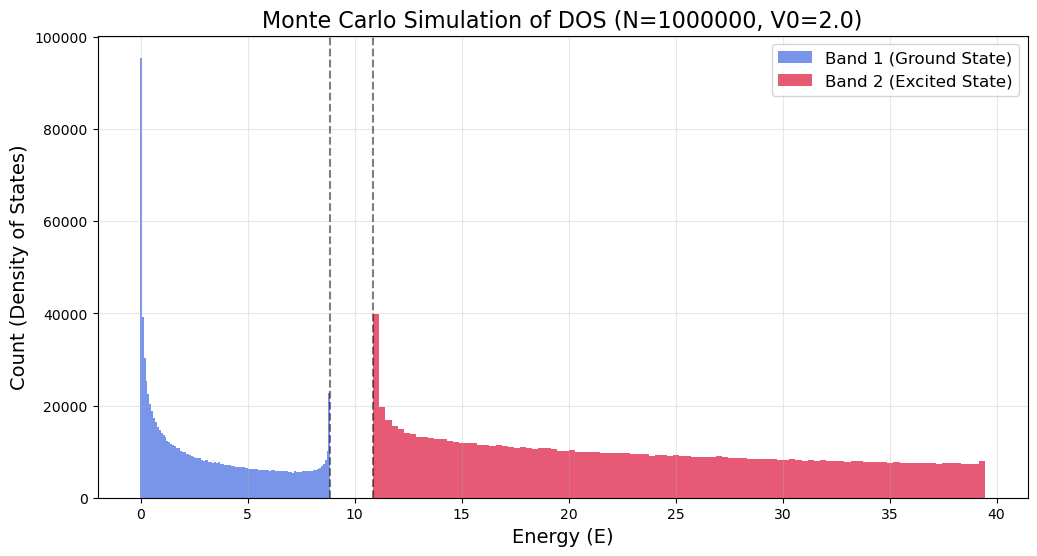

In [2]:
import matplotlib.pyplot as plt

# Monte Carlo Simulation
print("開始進行 Monte Carlo 模擬...")

# 1. Parameters setting
N_samples = 1000000    # total pts (here = 10,00000)
a = 1.0                # 晶格常數
V0 = 2.0               # potential energy 
N_waves = 11           # 基底數量 (matrix size)

# 2. Choose k value randomly. (On the range -n*pi/a to n*pi/a)
k_random_list = np.random.uniform(-3*np.pi/a, 3*np.pi/a, N_samples)

# 3. Data Collection
band1_energies = []  # ground state
band2_energies = []  # 1st excited state

for k in k_random_list:
    energies = get_nfe_energy(k, a, V0, N_waves)
    band1_energies.append(energies[0]) 
    band2_energies.append(energies[1])

print("模擬完成！開始繪圖...")

# Visualization
plt.figure(figsize=(12, 6))

# 繪製直方圖 (Histogram) 來模擬態密度 (DOS)
# bins=100 代表把能量切成 100 個小區間來統計數量
plt.hist(band1_energies, bins=100, color='royalblue', alpha=0.7, label='Band 1 (Ground State)')
plt.hist(band2_energies, bins=100, color='crimson', alpha=0.7, label='Band 2 (Excited State)')

plt.title(f'Monte Carlo Simulation of DOS (N={N_samples}, V0={V0})', fontsize=16)
plt.xlabel('Energy (E)', fontsize=14)
plt.ylabel('Count (Density of States)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# 標示出能隙區域 (根據我們之前的計算)
# 理論上 Gap 會出現在 8.85 到 10.85 之間
plt.axvline(x=8.857, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=10.857, color='k', linestyle='--', alpha=0.5)
plt.show()

##### Graphing the basic energy band.

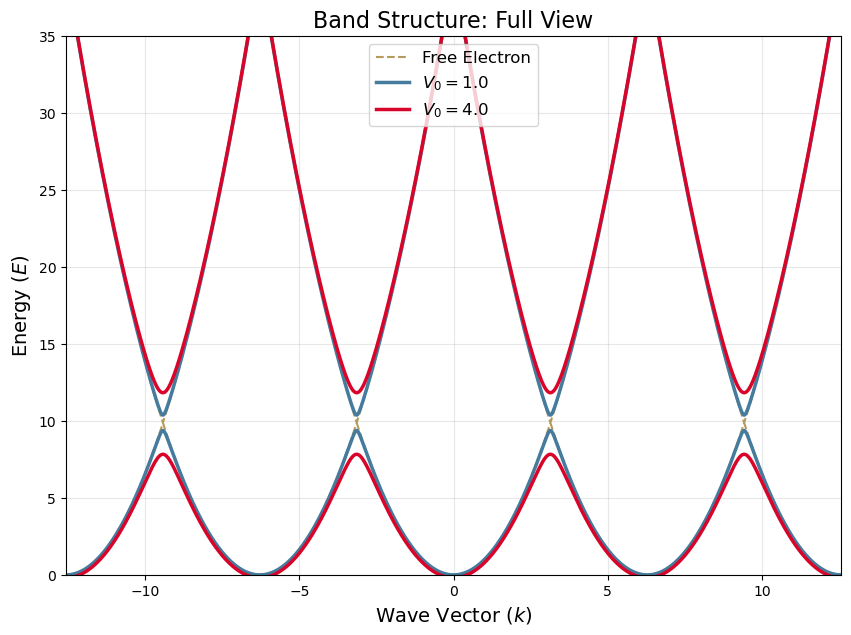

In [3]:
# 1. setting the parameters
a = 1
N_waves = 25
# 修改關鍵 1：掃描範圍改成左右對稱
k_scan = np.linspace(-4*np.pi/a, 4*np.pi/a, 1600) 

# 修改關鍵 2：把 V0 加大，效果才明顯！
# 0.0 (對照組), 1.0 (小裂縫), 4.0 (大裂縫)
V0_list = [0.0, 1.0, 4.0] 
colors = ['#b79a5b', '#457b9d', '#d90429'] 

plt.figure(figsize=(10, 7))

# 2. 迴圈跑不同的 V0
for V, c in zip(V0_list, colors):
    band1 = []
    band2 = []
    
    for k in k_scan:
        e = get_nfe_energy(k, a, V, N_waves)
        band1.append(e[0])
        band2.append(e[1])
    
    # 設定線條樣式
    ls = '--' if V == 0 else '-'     # V=0 用虛線
    lw = 1.5 if V == 0 else 2.5      # 其他加粗
    label_txt = 'Free Electron' if V == 0 else f'$V_0={V}$'

    plt.plot(k_scan, band1, color=c, linestyle=ls, linewidth=lw)
    plt.plot(k_scan, band2, color=c, linestyle=ls, linewidth=lw, label=label_txt)

# 3. set the view range
plt.ylim(0, 35)                   # Y-axis：從 0 開始，看到底部
plt.xlim(-4*np.pi/a, 4*np.pi/a)   # X-axis：左右對稱

plt.title('Band Structure: Full View', fontsize=16)
plt.xlabel('Wave Vector ($k$)', fontsize=14)
plt.ylabel('Energy ($E$)', fontsize=14)
plt.legend(fontsize=12, loc='upper center')
plt.grid(alpha=0.3)
plt.show()

Since the potential energy only to the cos1*x term(simpler form), let modify to have the more complex potential, such that we can calculate the more large sizes of matrix.(可以算更多主對角以外的動項)

正在進行蒙地卡羅掃描...


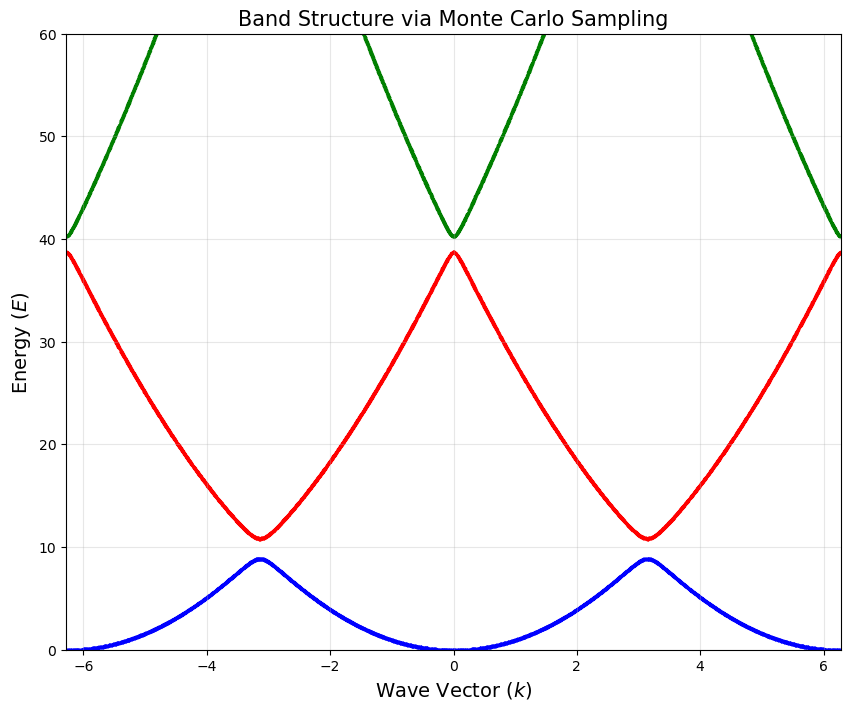

In [4]:
def get_nfe_energy_complex(k, a, V_params, N_waves):
    """
    V_params: a dictionary, e.g. {1: V1, 2: V2}
    represent that V(x) = V1*cos(2pi*x/a) + V2*cos(4pi*x/a)
    """
    n_min = -(N_waves // 2)
    n_max = (N_waves // 2) + 1
    G = 2 * np.pi / a * np.arange(n_min, n_max)
    H = np.zeros((N_waves, N_waves), dtype=complex)

    for i in range(N_waves):
        for j in range(N_waves):
            # T
            if i == j:
                H[i, j] = (k - G[i])**2
            # U(generalized)
            else:
                diff = abs(i - j)
                # 如果差 diff 格，且我們有設定該頻率的位能強度
                if diff in V_params:
                    H[i, j] = V_params[diff] / 2.0
                    
    energies, _ = eigh(H)
    return energies

# Use Monte Carlo method to graph the energy band(Scatter Plot)
a = 1.0
N_waves = 15
N_samples = 10000  
V_params = {1: 2.0, 2: 1.5} 

k_random = np.random.uniform(-2*np.pi/a, 2*np.pi/a, N_samples)
band_energies = []

print("正在進行蒙地卡羅掃描...")
for k in k_random:
    e = get_nfe_energy_complex(k, a, V_params, N_waves)
    # 我們把 (k, E) 這一對座標存起來
    # 這裡存前三條能帶
    band_energies.append([k, e[0], e[1], e[2]]) 

band_energies = np.array(band_energies)

plt.figure(figsize=(10, 8))

# with Scatter！
# s=2 代表點的大小，alpha=0.5 代表半透明
plt.scatter(band_energies[:, 0], band_energies[:, 1], s=2, c='blue', alpha=0.5, label='Band 1')
plt.scatter(band_energies[:, 0], band_energies[:, 2], s=2, c='red', alpha=0.5, label='Band 2')
plt.scatter(band_energies[:, 0], band_energies[:, 3], s=2, c='green', alpha=0.5, label='Band 3')

plt.title('Band Structure via Monte Carlo Sampling', fontsize=15)
#plt.title('Band Structure via Monte Carlo Sampling\n(Scatter Plot with Complex Potential)', fontsize=15)
plt.xlabel('Wave Vector ($k$)', fontsize=14)
plt.ylabel('Energy ($E$)', fontsize=14)
plt.xlim(-2*np.pi/a, 2*np.pi/a)
plt.ylim(0, 60)
plt.grid(alpha=0.3)

# 標示出原本尖尖的地方現在變怎樣了
#plt.text(0, 35, 'Gap Opened due to\n2nd order potential!', ha='center', color='red', fontweight='bold')
plt.show()

下面是用蒙地卡羅來化能階圖，因為我對於.gif的檔案創見完全不熟悉，所以就請gemini 幫忙創下化成動畫的乘式碼。

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from matplotlib.animation import FuncAnimation, PillowWriter  # 修正這裡：加了 r

# ==========================================
# 1. 核心計算函數
# ==========================================
def get_energy_cloud(k, a, V_params, N_waves):
    n_min = -(N_waves // 2)
    n_max = (N_waves // 2) + 1
    G = 2 * np.pi / a * np.arange(n_min, n_max)
    H = np.zeros((N_waves, N_waves), dtype=complex)

    for i in range(N_waves):
        for j in range(N_waves):
            if i == j:
                H[i, j] = (k - G[i])**2
            else:
                diff = abs(i - j)
                if diff in V_params:
                    H[i, j] = V_params[diff] / 2.0
    
    energies, _ = eigh(H)
    return energies

# ==========================================
# 2. 預先計算所有數據 (Pre-calculation)
# ==========================================
a = 1.0
N_waves = 11
Total_Samples = 10000  # 總共要跑多少點
V_params = {1: 2.0, 2: 1.5} # 複雜位能

print("正在預先計算所有數據，請稍候...")
k_all = []
e_all = [] 

k_random = np.random.uniform(-2*np.pi/a, 2*np.pi/a, Total_Samples)
for k in k_random:
    ens = get_energy_cloud(k, a, V_params, N_waves)
    # 存前三條能帶
    for i in range(3):
        k_all.append(k)
        e_all.append(ens[i])

k_all = np.array(k_all)
e_all = np.array(e_all)
print("計算完成！開始製作動畫...")

# ==========================================
# 3. 製作動畫 (Animation)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-2*np.pi/a, 2*np.pi/a)
ax.set_ylim(0, 60)
ax.set_xlabel('Wave Vector ($k$)', fontsize=14)
ax.set_ylabel('Energy ($E$)', fontsize=14)
ax.grid(alpha=0.3)

# 建立初始散布圖
scatter = ax.scatter([], [], s=1, c='midnightblue', alpha=0.3)
title = ax.set_title("Monte Carlo Sampling: N = 0", fontsize=16)

# 定義動畫的幀 (Frame)：我們要顯示的點數進度
frames = np.logspace(2, np.log10(Total_Samples), num=30).astype(int)

def update(frame_n):
    # frame_n 是現在要畫「幾個 k 點」
    # 因為每個 k 點有 3 個能階，所以數據長度是 3 * frame_n
    current_data_len = frame_n * 3
    
    # 更新數據
    scatter.set_offsets(np.c_[k_all[:current_data_len], e_all[:current_data_len]])
    
    # 更新標題
    title.set_text(f'Monte Carlo Convergence: N = {frame_n} samples')
    return scatter, title

# 建立動畫
anim = FuncAnimation(fig, update, frames=frames, interval=200, blit=False)

# 儲存
print("正在儲存 GIF...")
writer = PillowWriter(fps=10) # 修正後這裡可以正常運作了
anim.save("monte_carlo_band.gif", writer=writer)
print("完成！請查看 monte_carlo_band.gif")
plt.close()

正在預先計算所有數據，請稍候...
計算完成！開始製作動畫...
正在儲存 GIF...
完成！請查看 monte_carlo_band.gif


Show & save the gif pile. 

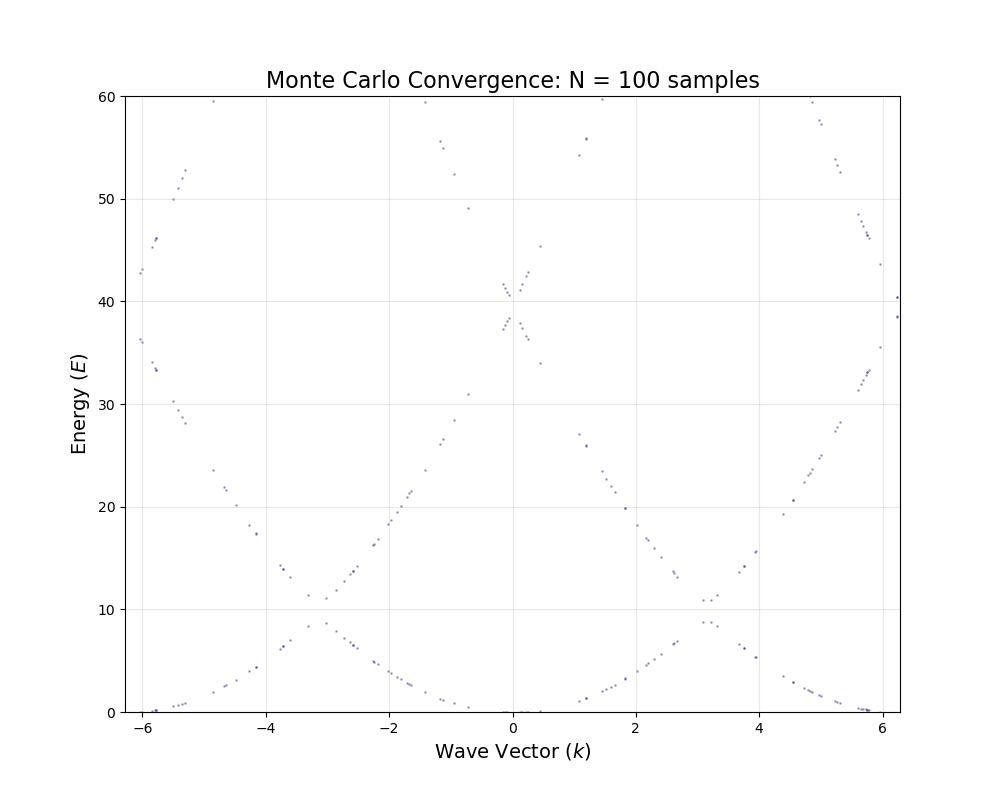

In [6]:
from IPython.display import Image

# 顯示剛剛存好的 GIF 檔案
Image(filename="monte_carlo_band.gif")

### Convergence test

正在進行收斂性測試 (這可能需要幾秒鐘)...


/tmp/ipykernel_688613/2622146917.py:37: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.loglog(N_list, errors, 'bo-', label='Simulation Error', c='#0466c8', markersize=8)


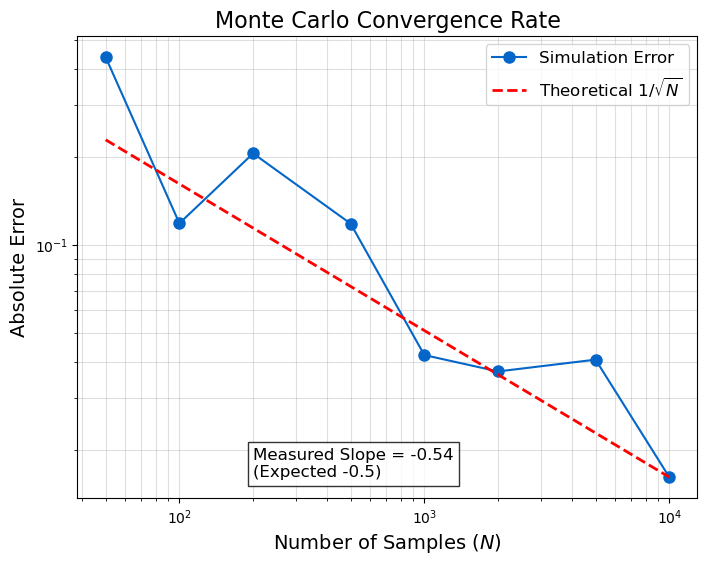

In [7]:
from scipy.stats import linregress

# 沿用你原本的 get_nfe_energy 函數 (假設已定義)
# 為了速度，我們把矩陣設小一點，位能單純一點
a = 1.0
V0 = 2.0
N_waves = 11

def calculate_mean_energy(N_samples):
    """用 N 個蒙地卡羅點計算第一能帶的平均能量"""
    k_random = np.random.uniform(-np.pi/a, np.pi/a, N_samples)
    total_energy = 0
    for k in k_random:
        e = get_nfe_energy(k, a, V0, N_waves)
        total_energy += e[0] # 只取第一能帶
    return total_energy / N_samples

print("正在進行收斂性測試 (這可能需要幾秒鐘)...")

# 1. 先算一個「超高精度」的標準答案 (當作真值)
True_Value = calculate_mean_energy(N_samples=100000) 

# 2. 測試不同的樣本數 N
N_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000]
errors = []

for N in N_list:
    # 為了避免單次運氣不好，每個 N 我們跑 5 次取平均誤差
    temp_errors = []
    for _ in range(5): 
        val = calculate_mean_energy(N)
        temp_errors.append(abs(val - True_Value))
    errors.append(np.mean(temp_errors))

# 3. Log-Log plot
plt.figure(figsize=(8, 6))
plt.loglog(N_list, errors, 'bo-', label='Simulation Error', c='#0466c8', markersize=8)

# 4. 畫出一條斜率為 -0.5 的參考線 (理論值 1/sqrt(N))
# 我們讓參考線通過最後一個點
ref_line = [errors[-1] * np.sqrt(N_list[-1]) / np.sqrt(n) for n in N_list]
plt.loglog(N_list, ref_line, 'r--', label=r'Theoretical $1/\sqrt{N}$', linewidth=2)

# 5. 計算並顯示實際斜率
slope, intercept, r_value, p_value, std_err = linregress(np.log10(N_list), np.log10(errors))
plt.text(200, errors[-1], f'Measured Slope = {slope:.2f}\n(Expected -0.5)', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.title('Monte Carlo Convergence Rate', fontsize=16)
plt.xlabel('Number of Samples ($N$)', fontsize=14)
plt.ylabel('Absolute Error', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.legend(fontsize=12)
plt.show()

這邊是用來討論truncation error的收斂速度：  
（發現收斂的速度真的蠻快的）

正在測試矩陣大小對能量的影響...


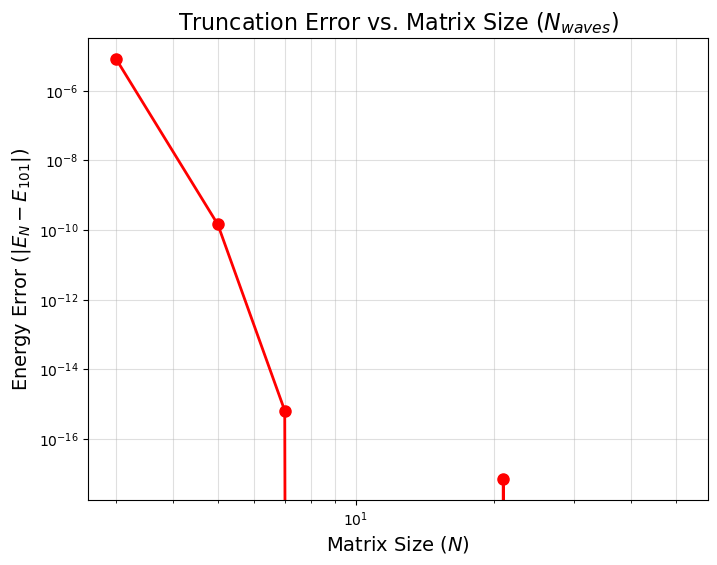

N_waves    | Energy          | Truncation Error
---------------------------------------------
3          | -0.05059575       | 8.09e-06
5          | -0.05060384       | 1.44e-10
7          | -0.05060384       | 6.45e-16
11         | -0.05060384       | 0.00e+00
21         | -0.05060384       | 6.94e-18
51         | -0.05060384       | 0.00e+00
101        | -0.05060384       | 0.00e+00


In [8]:
def get_energy_exact(k, a, V0, N_waves):
    n_min = -(N_waves // 2)
    n_max = (N_waves // 2) + 1
    G = 2 * np.pi / a * np.arange(n_min, n_max)
    H = np.zeros((N_waves, N_waves), dtype=complex)
    for i in range(N_waves):
        for j in range(N_waves):
            if i == j: H[i, j] = (k - G[i])**2
            elif abs(i - j) == 1: H[i, j] = V0 / 2.0
    energies, _ = eigh(H)
    return energies[0] # 回傳基態能量就好

# ==========================================
# 截斷誤差分析 (Truncation Error Analysis)
# ==========================================
a = 1.0
V0 = 2.0
k_point = 0.0 # 我們選一個固定的 k 點來測試 (例如 k=0)

# 測試不同的矩陣大小 (必須是奇數，保持對稱)
N_list = [3, 5, 7, 11, 21, 51, 101] 
energies = []

print("正在測試矩陣大小對能量的影響...")
for N in N_list:
    e = get_energy_exact(k_point, a, V0, N)
    energies.append(e)

# 假設 N=101 是「真值」 (因為它很大，誤差極小)
true_value = energies[-1] 
truncation_errors = [abs(e - true_value) for e in energies]

# ==========================================
# 繪圖
# ==========================================
plt.figure(figsize=(8, 6))

# 畫 Log-Log 圖，看誤差下降的速度
plt.loglog(N_list[:-1], truncation_errors[:-1], 'ro-', markersize=8, linewidth=2)

plt.title('Truncation Error vs. Matrix Size ($N_{waves}$)', fontsize=16)
plt.xlabel('Matrix Size ($N$)', fontsize=14)
plt.ylabel('Energy Error ($|E_N - E_{101}|$)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.show()

# 印出數值
print(f"{'N_waves':<10} | {'Energy':<15} | {'Truncation Error'}")
print("-" * 45)
for n, e, err in zip(N_list, energies, truncation_errors):
    print(f"{n:<10} | {e:.8f}       | {err:.2e}")